# Setup and Imports


In [5]:
import os
print(os.path.abspath('../src'))
print(os.listdir(os.path.abspath('../src')))

c:\Users\shree\Desktop\transceiver-project\src
['awgn.py', 'awgn_snr.py', 'data_utils.py', 'demodulator.py', 'hamming.py', 'modulator.py', 'plot_utils.py', 'sync.py', 'testing', '__init__.py', '__pycache__']


In [6]:
# Run this cell first in every notebook
import os
import sys

sys.path.append(os.path.abspath('../src'))

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

from demodulator import (
    downconvert_to_baseband,
    estimate_baseband_bandwidth,
    load_mono_normalized_audio,
    locate_pilot_start,
    matched_filter_sync,
    matched_filter_sync_new,
    slice_pilot_samples,
    downsample_from_offset,
    symbols_to_bits
)
from modulator import map_bits_to_symbols
from plot_utils import plot_complex_parts, plot_correlation_response, plot_fft
from sync import generate_zadoff_chu_audio
import awgn_snr
import config


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# System Parameters


In [7]:
# Match these exactly to TX.
FS = config.FS
F_CARRIER = config.F_CARRIER
SYMBOL_RATE = config.SYMBOL_RATE
SAMPLES_PER_SYMBOL = config.SAMPLES_PER_SYMBOL
ZC_ROOT = config.u_zadoff_chu
ZC_LENGTH = config.len_zadoff_chu
SYNC_GAP_SECONDS = config.SYNC_GAP_SECONDS

rx_path = '../data/tx_single_carrier_test.wav'



""" rx_path = '../data/tx_single_carrier_test.wav' """

" rx_path = '../data/tx_single_carrier_test.wav' "

# Load and Downconvert Audio


In [8]:
fs, rx_audio = load_mono_normalized_audio(rx_path)
if fs != FS:
    raise ValueError(f'Expected sample rate {FS}, got {fs}')

rx_audio_awgn = awgn_snr.add_awgn_snr(rx_audio,5)
#njfsbdjfbsdjf

(<Figure size 1200x400 with 1 Axes>,
 <Axes: title={'center': 'FFT'}, xlabel='Frequency [Hz]', ylabel='Magnitude'>)

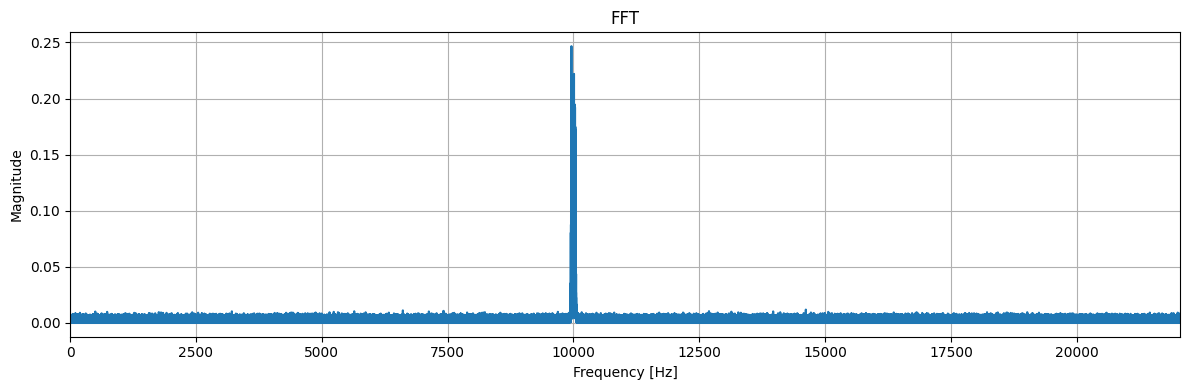

In [9]:
plot_fft(rx_audio_awgn,fs)

In [10]:
plot_fft(rx_baseband,fs)

NameError: name 'rx_baseband' is not defined

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Real Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>,
        <Axes: title={'center': 'Imaginary Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>],
       dtype=object))

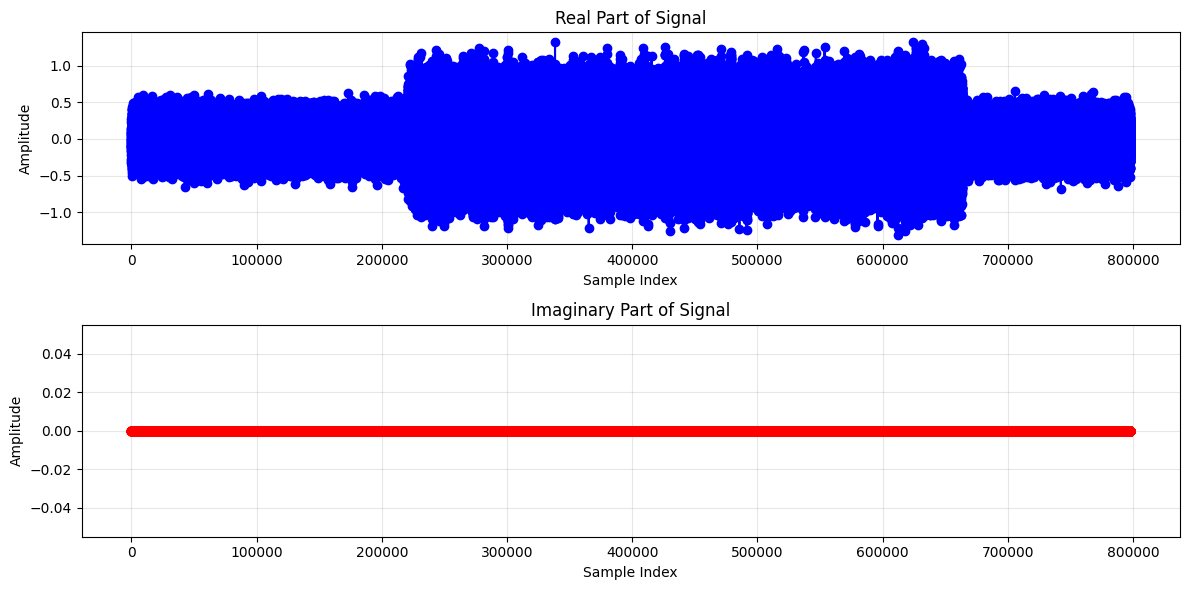

In [ ]:
plot_complex_parts(rx_audio_awgn)

In [ ]:
reference_zc = generate_zadoff_chu_audio(ZC_LENGTH, ZC_ROOT)
#zc_start_idx, corr = matched_filter_sync(rx_baseband, reference_zc)
zc_start_idx, corr = matched_filter_sync_new(
    rx_baseband,
    reference_zc,
    pulse_shape=config.pulse_method
)



pilot_start_idx = locate_pilot_start(
    sync_start_idx=zc_start_idx,
    sync_length=ZC_LENGTH,
    fs=FS,
    gap_seconds=SYNC_GAP_SECONDS,
)

print('-' * 50)
print(f'Zadoff-Chu peak found at sample index: {zc_start_idx}')
print(f'Known pilots begin at sample index: {pilot_start_idx}')
print('-' * 50)


--------------------------------------------------
Zadoff-Chu peak found at sample index: 300276
Known pilots begin at sample index: 300629
--------------------------------------------------


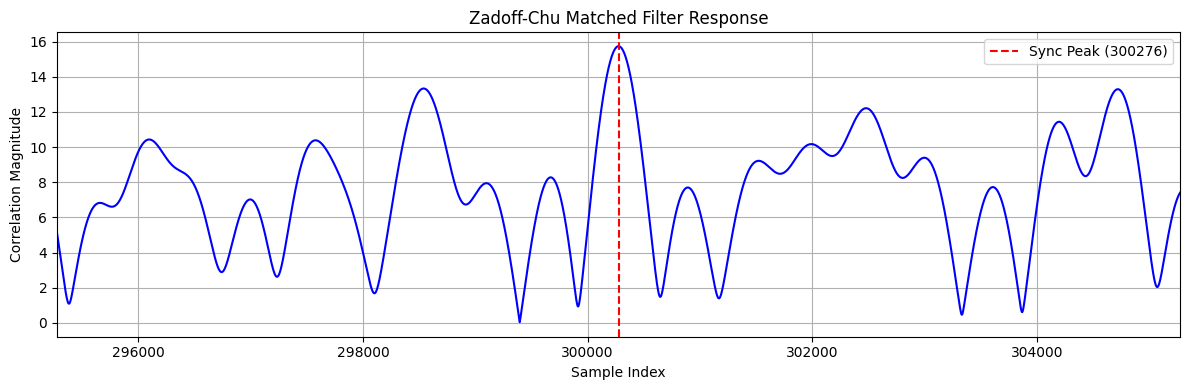

In [ ]:
plot_correlation_response(corr, zc_start_idx)
plt.show()


# Pilot Extraction


In [ ]:
pilot_bits = config.pilot_bits
pilot_symbols = map_bits_to_symbols(pilot_bits, config.M, METHOD=config.modulation_method)
KNOWN_PILOT_SYMBOLS = pilot_symbols

rx_pilots = slice_pilot_samples(
    rx_baseband=rx_baseband,
    pilot_start_idx=pilot_start_idx,
    num_pilot_symbols=len(KNOWN_PILOT_SYMBOLS),
    samples_per_symbol=SAMPLES_PER_SYMBOL,
)


(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Real Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>,
        <Axes: title={'center': 'Imaginary Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>],
       dtype=object))

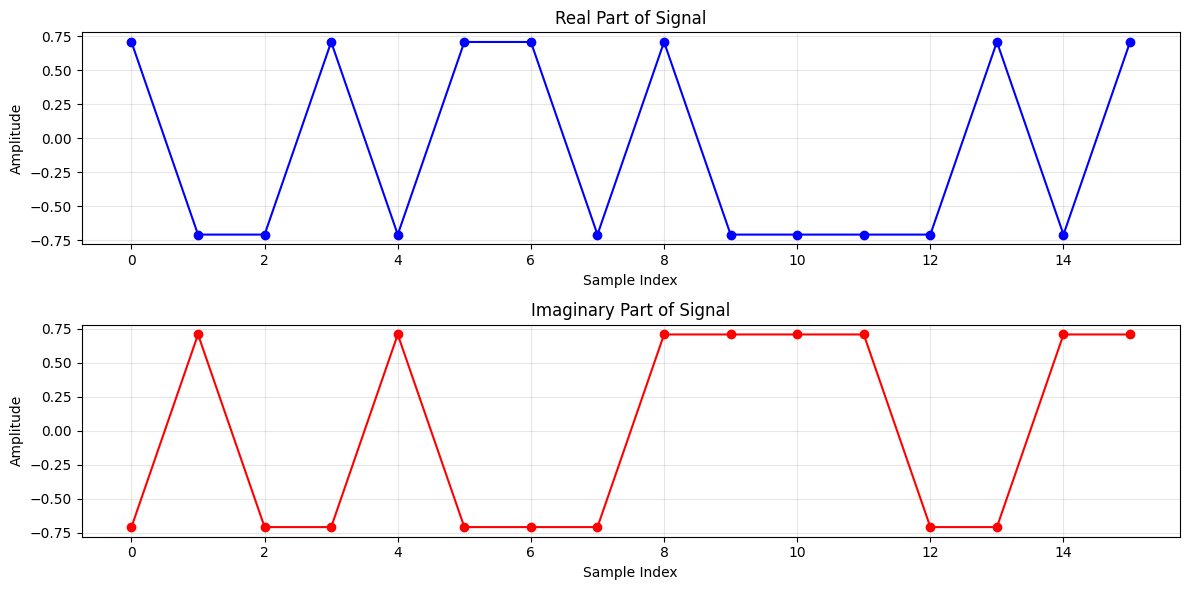

In [ ]:
plot_complex_parts(pilot_symbols)

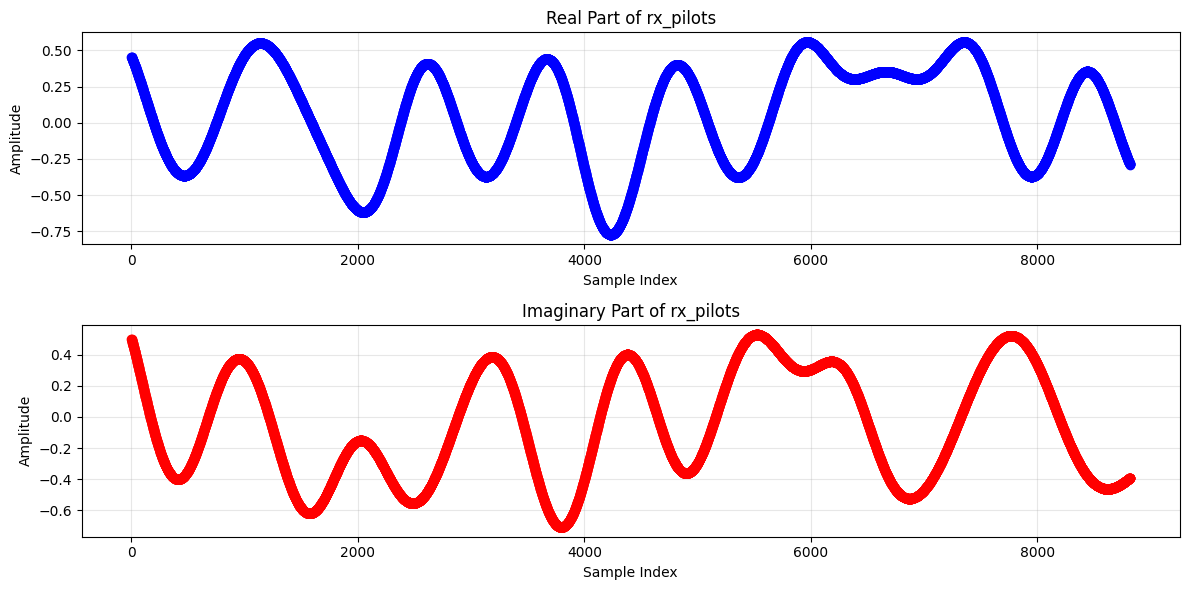

In [ ]:
plot_complex_parts(rx_pilots, title_prefix='rx_pilots')
plt.show()

### Synchronization 

Best offset inside pilot slice: 303


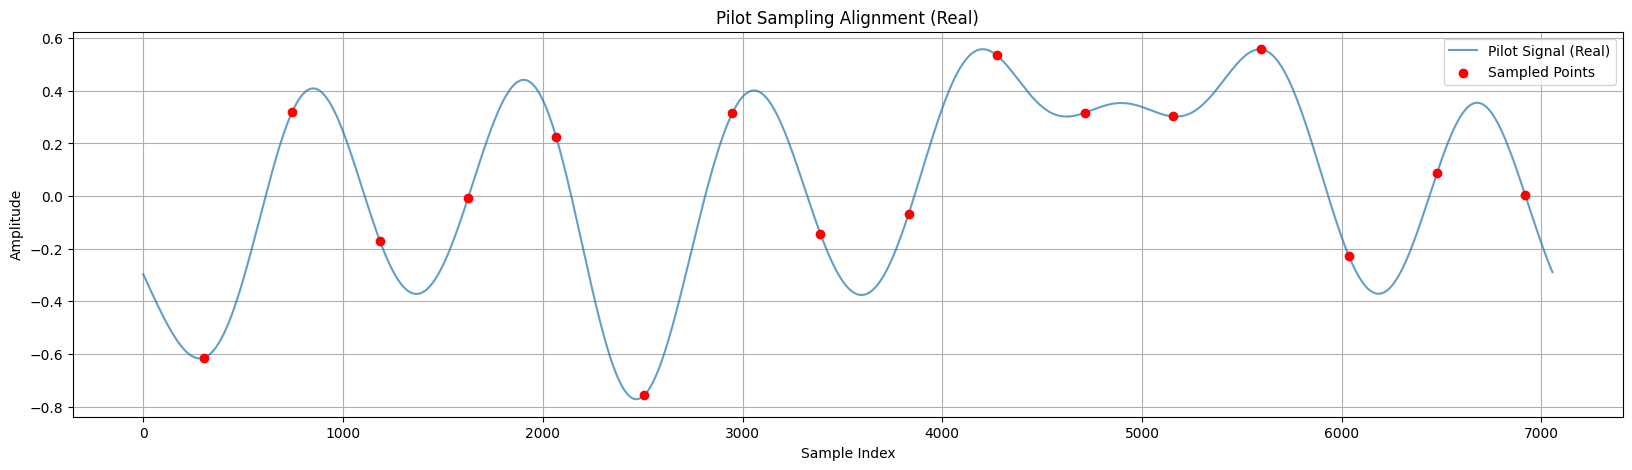

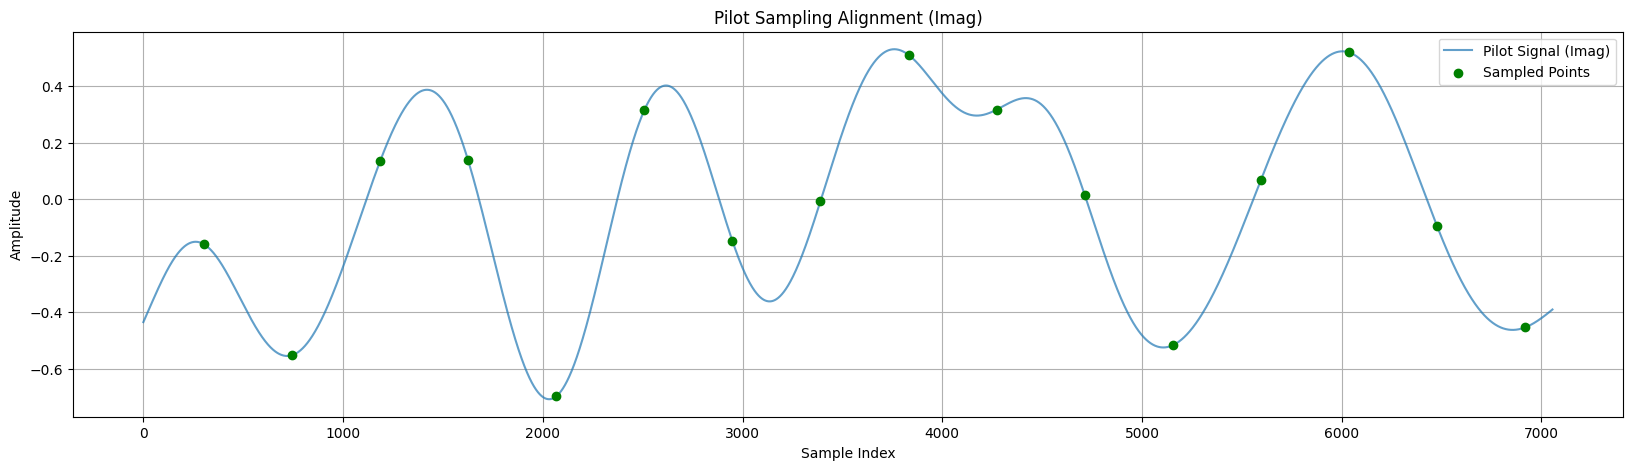


Known pilot symbols:
[ 0.70710678-0.70710678j -0.70710678+0.70710678j -0.70710678-0.70710678j
  0.70710678-0.70710678j -0.70710678+0.70710678j  0.70710678-0.70710678j
  0.70710678-0.70710678j -0.70710678-0.70710678j  0.70710678+0.70710678j
 -0.70710678+0.70710678j -0.70710678+0.70710678j -0.70710678+0.70710678j
 -0.70710678-0.70710678j  0.70710678-0.70710678j -0.70710678+0.70710678j
  0.70710678+0.70710678j]

Recovered pilot samples:
[-0.61442672-0.15952041j  0.31753617-0.55251002j -0.17174838+0.13359489j
 -0.00671547+0.13724838j  0.22382889-0.69798752j -0.75708786+0.31456294j
  0.31536992-0.14728316j -0.14379074-0.0072856j  -0.06927238+0.51063706j
  0.53545056+0.31673022j  0.31627904+0.01554344j  0.30247543-0.51713397j
  0.55727861+0.06773861j -0.22819792+0.51960048j  0.08768527-0.09511406j
  0.00512191-0.45396711j]


In [ ]:
L = SAMPLES_PER_SYMBOL
KNOWN = KNOWN_PILOT_SYMBOLS

# ================================
# REMOVE SINC DELAY REGION
# ================================
rxp = rx_pilots[config.SPAN * L:]

NUM_PILOTS = len(KNOWN)

# ================================
# FIND BEST OFFSET
# ================================
best_offset = 0
best_metric = -np.inf

for offset in range(L):
    samples = rxp[offset::L][:NUM_PILOTS]
    
    metric = np.abs(np.sum(samples * np.conj(KNOWN)))
    
    if metric > best_metric:
        best_metric = metric
        best_offset = offset

print(f"Best offset inside pilot slice: {best_offset}")

# ================================
# GET FINAL SAMPLE INDICES
# ================================
sample_indices = np.arange(best_offset, best_offset + NUM_PILOTS*L, L)

# ================================
# PLOT REAL PART
# ================================
import matplotlib.pyplot as plt

plt.figure(figsize=(20,5))

plt.plot(np.real(rxp), label="Pilot Signal (Real)", alpha=0.7)

plt.scatter(sample_indices,
            np.real(rxp[sample_indices]),
            color='red',
            label="Sampled Points",
            zorder=5)

plt.title("Pilot Sampling Alignment (Real)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()

# ================================
# PLOT IMAG PART
# ================================
plt.figure(figsize=(20,5))

plt.plot(np.imag(rxp), label="Pilot Signal (Imag)", alpha=0.7)

plt.scatter(sample_indices,
            np.imag(rxp[sample_indices]),
            color='green',
            label="Sampled Points",
            zorder=5)

plt.title("Pilot Sampling Alignment (Imag)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()

# ================================
# VERIFY SYMBOLS
# ================================
rx_samples = rxp[best_offset::L][:NUM_PILOTS]

print("\nKnown pilot symbols:")
print(KNOWN)

print("\nRecovered pilot samples:")
print(rx_samples)

In [ ]:
start = pilot_start_idx + config.SPAN * L + best_offset

downsampled_symbols, ds_signal = downsample_from_offset(
    rx_baseband,
    start,
    L
)

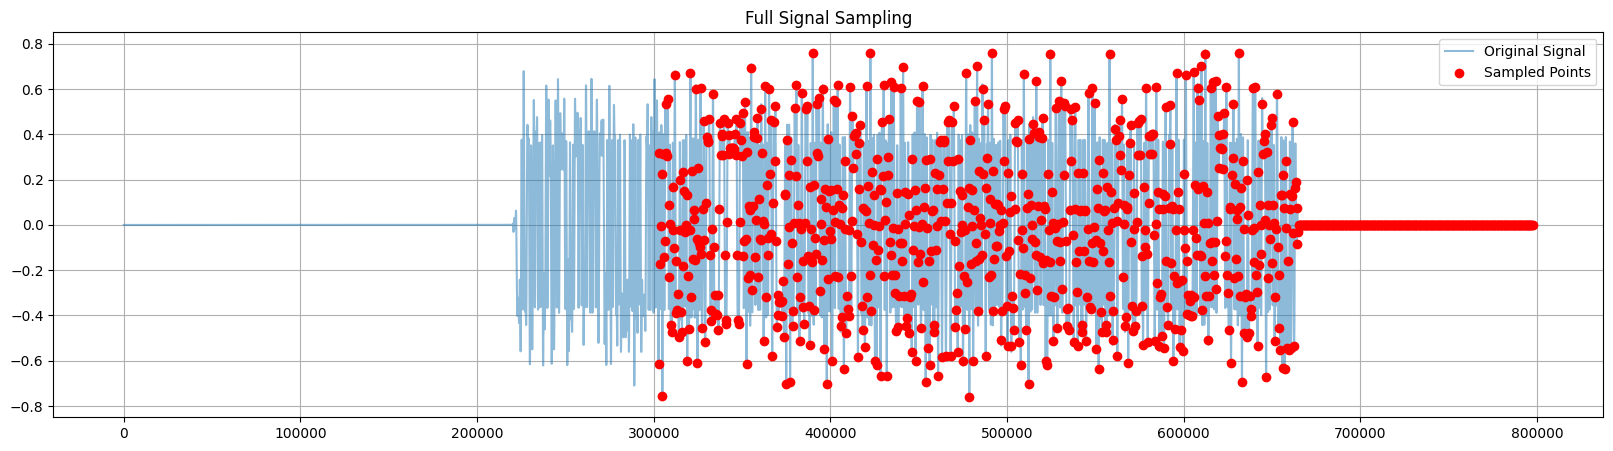

In [ ]:
plt.figure(figsize=(20,5))

plt.plot(np.real(rx_baseband), label="Original Signal", alpha=0.5)

sample_indices = np.arange(start, len(rx_baseband), L)

plt.scatter(sample_indices,
            np.real(rx_baseband[sample_indices]),
            color='red',
            label="Sampled Points",
            zorder=5)

plt.title("Full Signal Sampling")
plt.grid(True)
plt.legend()
plt.show()

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Real Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>,
        <Axes: title={'center': 'Imaginary Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>],
       dtype=object))

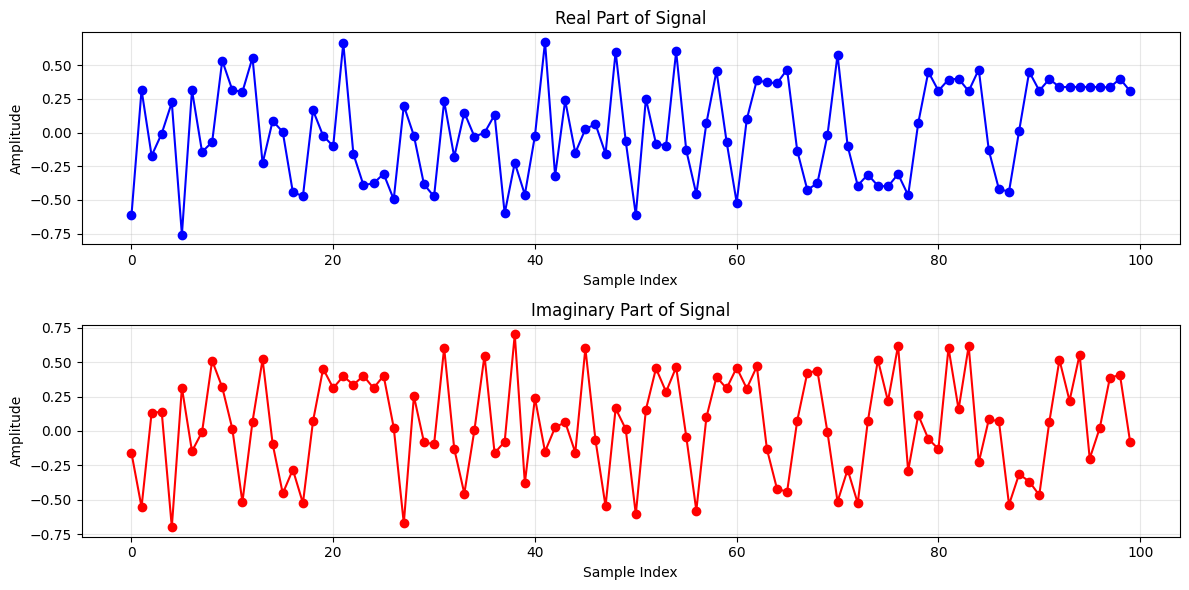

In [ ]:
plot_complex_parts(rx_baseband[sample_indices][0:100])

In [ ]:
recovered_bits = symbols_to_bits(
    downsampled_symbols,
    M=config.M,
    METHOD=config.modulation_method
)

In [ ]:
input_path = "../data/message.txt"
with open(input_path, "r") as f:
        data_binary = f.read().strip()


# Calculate Bit Error Rate (BER)
recovered_bit_string = ''.join(map(str, recovered_bits))

# Determine the length to compare (use the shorter length or match as needed)
min_length = min(len(recovered_bit_string), len(data_binary))

# Compare bits
bit_errors = sum(r != d for r, d in zip(recovered_bit_string[:min_length], data_binary[:min_length]))

# Calculate BER
ber = bit_errors / min_length if min_length > 0 else 0

print(f"Recovered bits: {recovered_bit_string[:min_length]}")
print(f"Original bits:  {data_binary[:min_length]}")
print(f"\nTotal bits compared: {min_length}")
print(f"Bit errors: {bit_errors}")
print(f"Bit Error Rate (BER): {ber:.6f} ({ber*100:.2f}%)")

Recovered bits: 001001011001100001111110110110100000110101110101010101100100001100100101100001000110011100111000110100110101110000111101011111101010010101001000000101010100111010111111100101001010101111111110111111101001000010111010100101110000100011110010001111100010101101110000101111011111011001001011110101111111110100000101010100010000111001100000110011010000101110110110110000001000010110101010010100100100110110000011101010001010001000011110001001110000110111100011111110001110000111100110000100010100110110101110111010010110101001010110110111100011110110001101001001010011010111001111101000101101101111000110010110010001110100000010010010011110010010100001000011010011001110000110010111110011100011010100001001101100011100011000111010100110101111011110101000011011101001000100001000110101110000000111011010011000011100111001011001110111110011101100001110100011110111011001110010011100111100001110101000010111011011000001001010111111010001011101001101010110110111001001001111000110001110110111

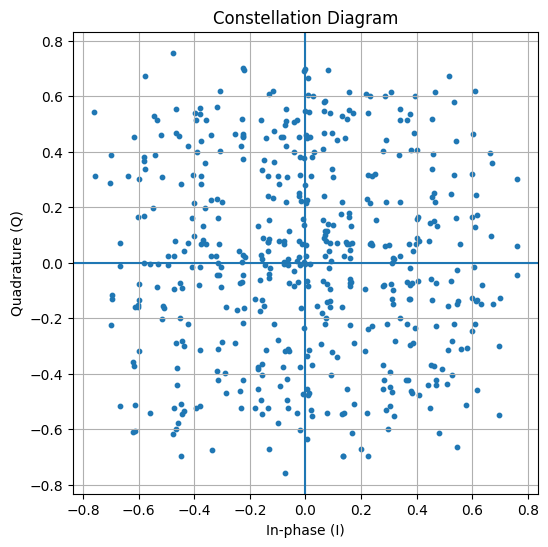

In [ ]:
plt.figure(figsize=(6,6))

no_of_symbols_to_plot = 500
downsampled_symbols = downsampled_symbols[: no_of_symbols_to_plot]

plt.scatter(np.real(downsampled_symbols),
            np.imag(downsampled_symbols),
            s=10)

plt.axhline(0)
plt.axvline(0)

plt.title("Constellation Diagram")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.grid(True)
plt.axis('equal')

plt.show()